# L'énigmatique jardin d'iris

## Introduction et démarche

En tant que data scientists en herbe, notre mission est de percer les mystères d'un jardin botanique abritant trois espèces d'Iris: Setosa, Versicolor et Virginica. Pour y parvenir, nous allons construire et comparer des modèles d'apprentissage automatique capables de distinguer ces trois fleurs.

Nous nous appuierons sur l'ensemble de données Iris, qui rassemble les mesures méticuleuses des dimensions des sépales et des pétales pour 150 spécimens.

Notre parcours suivra une méthodologie rigoureuse:

1. **Exploration des données**: Familiarisation avec la structure du dataset et production de statistiques descriptives.
2. **Ingénierie des caractéristiques et Modélisation**: De manière à garantir un code propre et robuste, nous utiliserons l'outil Pipeline. Cela nous permettra d'enchaîner la standardisation, la réduction de dimension via PCA pour extraire l'essence des mesures , et l'entraînement de différents classifieurs (k-NN, Régression Logistique, Arbre de décision).
3. **Évaluation et Perspectives**: Nous testerons ces modèles sur des échantillons non vus pour évaluer leurs métriques et nous analyserons leurs performances respectives pour dévoiler les secrets de ce jardin.

## 1. Exploration des données

In [13]:
# ---------------------------------------------
# 1. Imports pour la manipulation de données
# ---------------------------------------------
import pandas as pd
import numpy as np

# ---------------------------------------------
# 2. Imports pour la visualisation (EDA)
# ---------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------
# 3. Imports de Scikit-Learn (Machine Learning)
# ---------------------------------------------
# Chargement du dataset
from sklearn.datasets import load_iris

# Préparation et séparation des données
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Réduction de dimension
from sklearn.decomposition import PCA

# Modèles de classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Construction de Pipeline
from sklearn.pipeline import Pipeline

# Métriques d'évaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
# Chargement du dataset fourni par Scikit-Learn
iris_set = load_iris()
iris = pd.DataFrame(data=iris_set.data, columns=iris_set.feature_names)

# Ajout de la variable cible (les étiquettes : 0, 1 ou 2)
iris['target'] = iris_set.target

dictionnaire_especes = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
iris['species_name'] = iris['target'].map(dictionnaire_especes)

# Affichage des 5 premières lignes
display(iris.head())

# Affichage des statistiques descriptives
display(iris.describe())

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(iris.isnull().sum())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Valeurs manquantes par colonne :
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species_name         0
dtype: int64


Avant de passer à la préparation des données, visualisons les relations entre nos différentes variables pour voir si des groupes naturels se dessinent selon les espèces.

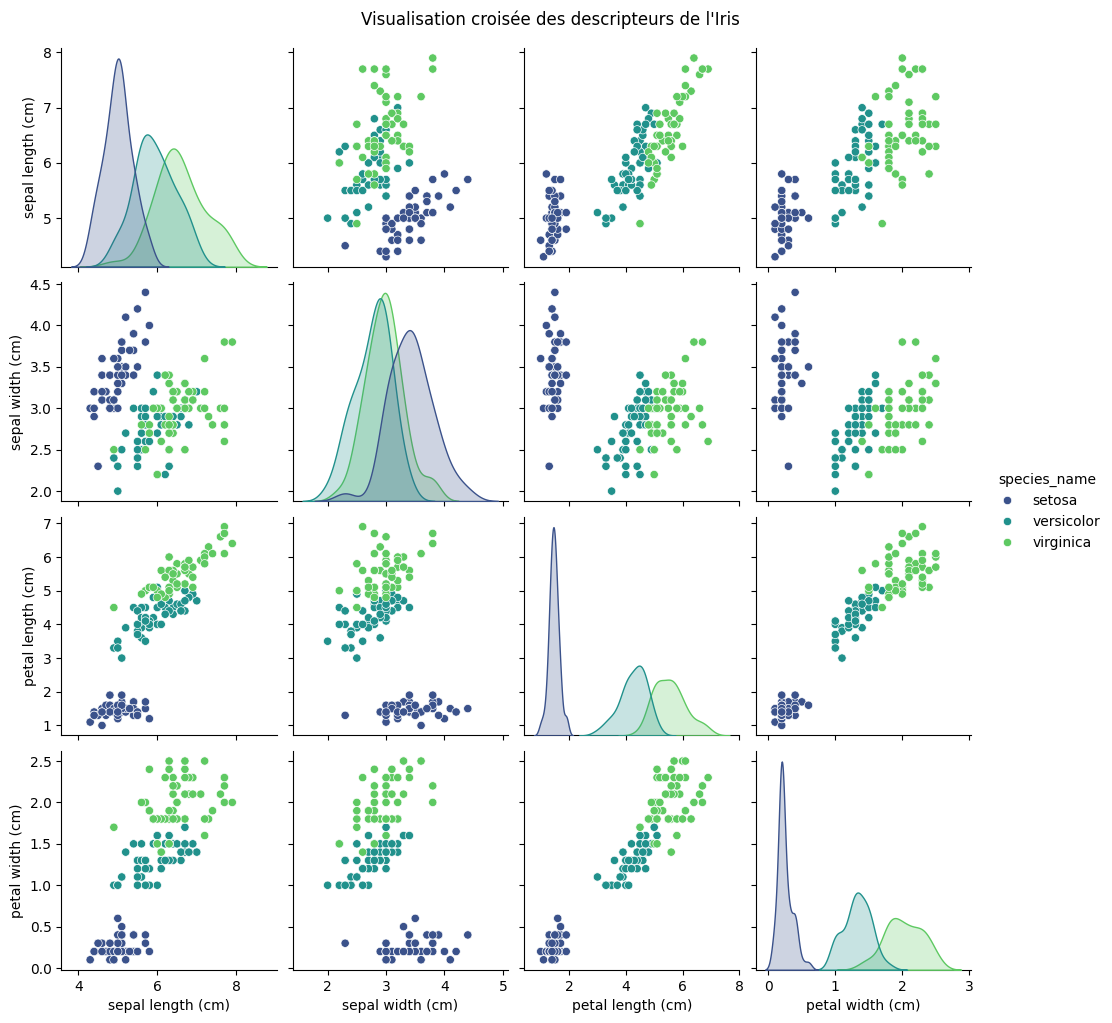

In [15]:
# Création d'un graphique croisant toutes les variables
sns.pairplot(iris.drop('target', axis=1), hue='species_name', palette='viridis')
plt.suptitle("Visualisation croisée des descripteurs de l'Iris", y=1.02)
plt.show()

## 2. Préparation des données
Avant de confier nos données à un algorithme d'apprentissage, deux étapes cruciales s'imposent:
1. **Séparer nos données:** Nous allons isoler 20% de nos observations pour tester notre futur modèle sur des échantillons de données non vus par le modèle.
2. **Réduire la dimensionnalité (PCA):** Notre objectif est de transformer les 4 mesures brutes en signaux informatifs réduits. Avant d'automatiser cette étape dans notre Pipeline, nous allons réaliser une _Analyse en Composantes Principales (PCA)_ isolée. Cela nous permettra de visualiser concrètement si cette réduction permet de bien séparer nos trois espèces d'iris.

In [16]:
# 1. Séparation des caractéristiques (X) et de la cible (y)
X = iris.drop(['target', 'species_name'], axis=1) 
y = iris['target']

# 2. Découpage: 80% pour l'entraînement, 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille du jeu d'entraînement : {X_train.shape[0]} fleurs")
print(f"Taille du jeu de test : {X_test.shape[0]} fleurs")

Taille du jeu d'entraînement : 120 fleurs
Taille du jeu de test : 30 fleurs


Pour comprendre l'utilité de notre ingénierie des caractéristiques, projetons nos données d'entraînement (qui possèdent 4 dimensions) sur un plan en 2 dimensions (2 composantes principales).

> Il est indispensable de centrer et réduire (standardiser) les données avant d'appliquer une PCA pour que chaque mesure ait le même poids.

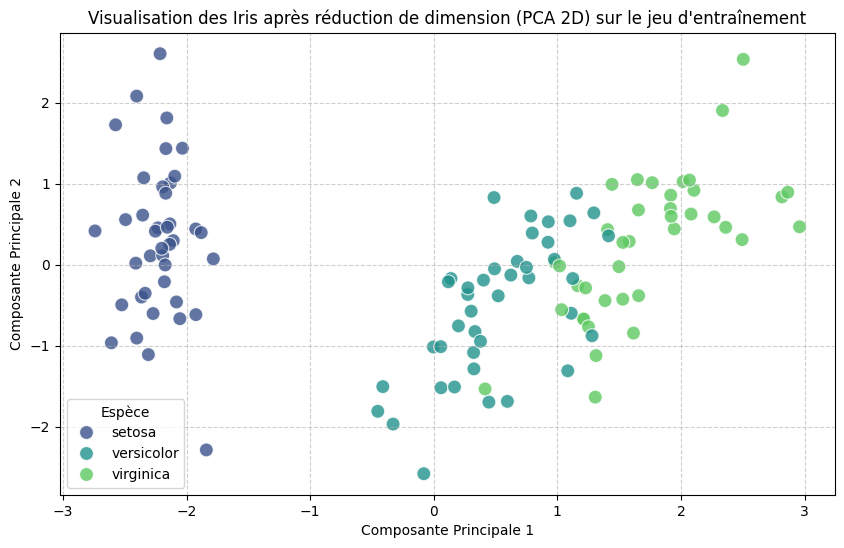

In [17]:
# 1. Standardisation
scaler_visu = StandardScaler()
X_train_scaled = scaler_visu.fit_transform(X_train)

# 2. Application de la PCA
pca_visu = PCA(n_components=2)
X_train_pca = pca_visu.fit_transform(X_train_scaled)

# 3. Création d'un DataFrame pour faciliter l'affichage avec Seaborn
df_pca_visu = pd.DataFrame(data=X_train_pca, columns=['Composante Principale 1', 'Composante Principale 2'])

df_pca_visu['Espèce'] = y_train.map(dictionnaire_especes).values

# 4. Affichage du nuage de points
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Composante Principale 1', 
    y='Composante Principale 2', 
    hue='Espèce', 
    palette='viridis', 
    data=df_pca_visu,
    s=100, alpha=0.8 # Taille et transparence des points
)

plt.title("Visualisation des Iris après réduction de dimension (PCA 2D) sur le jeu d'entraînement")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Interprétation
Le graphique confirme que notre stratégie de réduction est pertinente. On observe que l'espèce Setosa forme un groupe (cluster) extrêmement distinct des deux autres. Les espèces Versicolor et Virginica sont un peu plus proches, mais la PCA parvient tout de même à créer une frontière de décision naturelle visible. Cela valide notre choix d'intégrer une PCA (avec n_components=2) dans nos futurs pipelines de classification !

## 3. Modélisation

Maintenant que nous avons validé visuellement l'intérêt de la réduction de dimension, nous allons construire nos modèles de classification.
Afin de garantir la reproductibilité, d'éviter les fuites de données (data leakage) et de garder un code élégant, nous allons encapsuler nos traitements dans des **Pipelines**.

Chaque pipeline enchaînera trois étapes de manière automatisée:

1. **StandardScaler:** Mise à l'échelle des données (moyenne à 0, variance à 1).
2. **PCA:** Réduction de la dimensionnalité à 2 composantes principales.
3. **Classifieur:** L'algorithme d'apprentissage automatique supervisé.

Nous allons expérimenter et comparer trois algorithmes différents pour déterminer lequel est le plus performant pour notre problématique:
- Les k-plus proches voisins (k-NN)
- La régression logistique
- L'arbre de décision

In [18]:
# ---------------------------------------------
# Définition des 3 Pipelines de Modélisation
# ---------------------------------------------

# Pipeline 1: k-Nearest Neighbors (k-NN)
# Hyperparamètre à expérimenter : n_neighbors (le nombre de voisins)
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('classifier', KNeighborsClassifier(n_neighbors=5)) 
])

# Pipeline 2: régression logistique
# Hyperparamètre à expérimenter : C (l'inverse de la force de régularisation)
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('classifier', LogisticRegression(random_state=42))
])

# Pipeline 3 : Arbre de Décision
# Hyperparamètre à expérimenter : max_depth (profondeur maximale de l'arbre)
pipeline_dtree = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=3))
])

print("Les 3 pipelines ont été instanciés avec succès !")

Les 3 pipelines ont été instanciés avec succès !


### Entraînement des Modèles
Nous allons maintenant entraîner (fit) nos trois pipelines simultanément sur nos données d'entraînement (X_train et y_train). Le pipeline se chargera de standardiser, de calculer la PCA et d'ajuster le modèle en une seule ligne de code par algorithme.

In [19]:
# Entraînement des modèles sur les données d'apprentissage
pipeline_knn.fit(X_train, y_train)
pipeline_logreg.fit(X_train, y_train)
pipeline_dtree.fit(X_train, y_train)

print("Entraînement terminé pour les 3 modèles.")

Entraînement terminé pour les 3 modèles.


### Prédictions sur le jeu de test
Nos modèles ayant appris les règles de classification sur le jeu d'entraînement, nous allons les confronter à notre jeu de test (X_test), qui contient 20% des données qu'ils n'ont encore jamais vues.

In [20]:
# Génération des prédictions pour chaque modèle
y_pred_knn = pipeline_knn.predict(X_test)
y_pred_logreg = pipeline_logreg.predict(X_test)
y_pred_dtree = pipeline_dtree.predict(X_test)

print("Prédictions générées avec succès. Prêts pour l'évaluation !")

Prédictions générées avec succès. Prêts pour l'évaluation !


## 4. Évaluation et validation
L'heure de vérité a sonné ! Nous allons tester nos trois modèles de classification sur nos échantillons de test (les 20% de données isolées au début).

Pour évaluer différentes métriques, nous allons utiliser:
- **L'exactitude (Accuracy):** Pour avoir un score global de performance.
- **La matrice de confusion:** Pour comprendre exactement où nos modèles se trompent et s'ils confondent certaines espèces plus que d'autres.

In [21]:
# ---------------------------------------------
# 1. Évaluation globale (Accuracy)
# ---------------------------------------------

# Calcul des scores d'exactitude
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
acc_dtree = accuracy_score(y_test, y_pred_dtree)

print("=== Performances globales sur le jeu de test ===")
print(f"k-NN                 : {acc_knn * 100:.2f}% de bonnes prédictions")
print(f"Régression Logistique: {acc_logreg * 100:.2f}% de bonnes prédictions")
print(f"Arbre de Décision    : {acc_dtree * 100:.2f}% de bonnes prédictions")

=== Performances globales sur le jeu de test ===
k-NN                 : 93.33% de bonnes prédictions
Régression Logistique: 90.00% de bonnes prédictions
Arbre de Décision    : 90.00% de bonnes prédictions


Mais... l'accuracy ne fait pas tout. Affichons les matrices de confusion pour visualiser concrètement quelles sont les espèces qui posent problème à nos algorithmes. La diagonale représente les bonnes prédictions, et les cases en dehors de la diagonale représentent les erreurs.

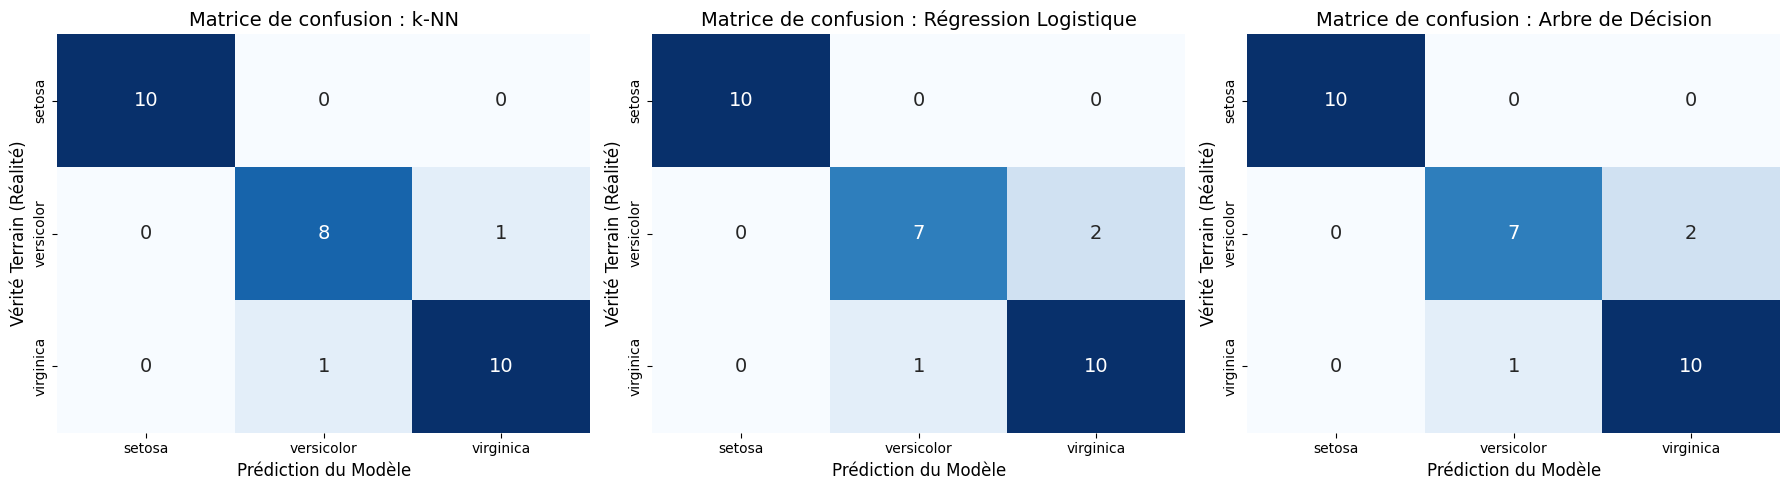

In [22]:
# ---------------------------------------------
# 2. Évaluation détaillée (Matrices de confusion)
# ---------------------------------------------

# Création d'une figure avec 3 sous-graphiques (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Liste de nos modèles et de leurs prédictions pour faire une boucle propre
modeles = [
    ("k-NN", y_pred_knn), 
    ("Régression Logistique", y_pred_logreg), 
    ("Arbre de Décision", y_pred_dtree)
]

# Les noms des espèces pour les axes
labels_especes = ['setosa', 'versicolor', 'virginica']

# Boucle pour tracer les 3 matrices
for i, (nom_modele, y_pred) in enumerate(modeles):
    # Calcul de la matrice
    cm = confusion_matrix(y_test, y_pred)
    
    # Création du graphique heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels_especes, yticklabels=labels_especes,
                cbar=False, annot_kws={"size": 14})
    
    # Ajout des titres et labels
    axes[i].set_title(f"Matrice de confusion : {nom_modele}", fontsize=14)
    axes[i].set_xlabel('Prédiction du Modèle', fontsize=12)
    axes[i].set_ylabel('Vérité Terrain (Réalité)', fontsize=12)

plt.tight_layout()
plt.show()

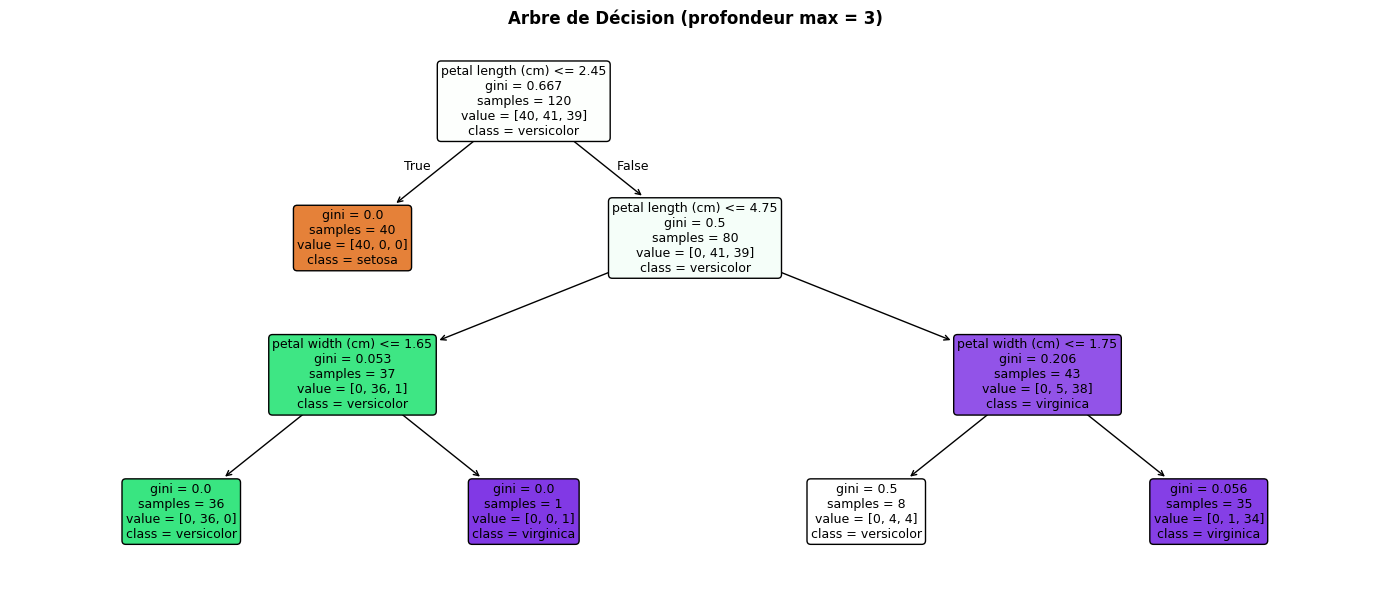

Accuracy arbre (test) : 1.000


In [23]:
# Entraîner un arbre de décision simple pour l'interpréter
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(14, 6))
plot_tree(dt,
          feature_names=iris_set.feature_names,
          class_names=iris_set.target_names,
          filled=True, rounded=True, fontsize=9)
plt.title('Arbre de Décision (profondeur max = 3)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Accuracy arbre (test) : {accuracy_score(y_test, dt.predict(X_test)):.3f}')

## 5. Perspectives et interprétation: Les secrets du Jardin d'Iris
Pour clore notre exploration, analysons plus en profondeur la significativité de nos résultats. Nous allons générer le rapport de classification détaillé pour notre modèle de **régression logistique** afin d'observer les performances classe par classe.

In [24]:
# ---------------------------------------------
# 3. Rapport de classification détaillé
# ---------------------------------------------

print("--- Rapport de Classification : Régression Logistique avec PCA (2D) ---\n")

# On génère le rapport en utilisant les vrais noms des cibles pour la lisibilité
rapport = classification_report(
    y_test, 
    y_pred_logreg, 
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

print(rapport)

--- Rapport de Classification : Régression Logistique avec PCA (2D) ---

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.88      0.78      0.82         9
   Virginica       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### Interprétation des performances en fonction des descripteurs

En analysant la performance de nos algorithmes d'apprentissage automatique, nous pouvons tirer plusieurs conclusions fascinantes sur la nature de ces fleurs:

1. **L'isolement de l'Iris Setosa:** Que ce soit avec le k-NN, l'Arbre de décision ou la Régression Logistique, la classe _Setosa_ est toujours prédite avec une exactitude parfaite. En nous référant à notre nuage de points issu de l'ingénierie des caractéristiques (PCA), nous avions en effet constaté que les descripteurs réduits de la Setosa formaient un groupe totalement isolé. Ses mensurations sont uniques.
2. **La frontière floue entre Versicolor et Virginica:** Les quelques erreurs d'étiquetage observées dans nos matrices de confusion se situent exclusivement entre ces deux espèces. Cela confirme notre exploration visuelle: dans un espace réduit à 2 dimensions (PCA), les caractéristiques de ces deux fleurs ont tendance à se chevaucher.

Le choix du modèle: (Ajouter ici une phrase pour désigner le grand gagnant parmi les 3, ex.: "La Régression Logistique s'est révélée être le modèle le plus robuste sur nos données de test...")

## Conclusion

À travers ce projet, nous avons pu démêler la tapisserie énigmatique du jardin d'iris. L'utilisation de **pipelines** nous a permis de traiter efficacement les mesures brutes et de construire des modèles prédictifs robustes, démontrant ainsi toute la puissance de la classification supervisée en science des données.